In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.fft import fft, ifft, fftfreq
import librosa as lb
%matplotlib widget


#----------------------------------------------------------------------------------------------
#  
#----------------------------------------------------------------------------------------------


"""----------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------"""

def unwind(a):
    return np.roll(a, len(a) // 2)

def Generator(filename):
   """----------------------------------------------------------------------------------------------
   Reading the file and calculating important quantities, including our FFT
   ----------------------------------------------------------------------------------------------"""

   Waveform, Sample_Rate = lb.load(filename)
   Duration = len(Waveform) / Sample_Rate
   print(f"The duration of the recording is {Duration}")
   Time = np.arange(0, Duration, 1/Sample_Rate)
   Nyquist_Frequency = Sample_Rate / 2
   FFT = fft(Waveform)
   return Waveform, Time, Nyquist_Frequency, FFT

def Plotter(Waveform, Time, Nyquist_Frequency, FFT, Start_ratio, End_ratio):
   fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(11, 8))
   fig.suptitle("Waveform and FFT Analysis")
   """----------------------------------------------------------------------------------------------
   Graphing our Waveform
   ----------------------------------------------------------------------------------------------"""
   #----------------------------------------------------------------------------------------------
   #   We need to know what the .wav file is taking in. What is our Y-axis
   #----------------------------------------------------------------------------------------------
   start_time = int(Start_ratio * len(Waveform))
   end_time = int(End_ratio * len(Waveform))


   ax[0][0].plot(Time[start_time:end_time], np.real(Waveform)[start_time:end_time], label = "Real Waveform")
   ax[0][0].set_title("Waveform: real part")
   ax[0][0].set_xlabel("Time [s]")
   ax[0][0].set_ylabel("Amplitude")
   ax[0][1].plot(Time[start_time:end_time], np.imag(Waveform)[start_time:end_time], label = "Imaginary Waveform")
   ax[0][1].set_title("Waveform: imaginary part")
   ax[0][1].set_xlabel("Time [s]")
   ax[0][1].set_ylabel("Amplitude")

   Freqs = fftfreq( len(FFT), 1/len(FFT) )
   FFT_Real = np.real(FFT)
   FFT_Imag = np.imag(FFT)

   ax[1][0].plot(unwind(Freqs), unwind(FFT_Real), label = "Real FFT")
   ax[1][0].set_title("Full FFT: real part")
   ax[1][0].set_xlim(-Nyquist_Frequency, Nyquist_Frequency)
   ax[1][0].set_xlabel("Frequency [Hz]")
   ax[1][0].set_ylabel("Real coefficient")
   ax[1][1].plot(unwind(Freqs), unwind(FFT_Imag), label = "Imaginary FFT")
   ax[1][1].set_title("Full FFT: imaginary part")
   ax[1][1].set_xlim(-Nyquist_Frequency, Nyquist_Frequency)
   ax[1][1].set_xlabel("Frequency [Hz]")
   ax[1][1].set_ylabel("Imaginary coefficient")

   #----------------------------------------------------------------------------------------------
   #   Here I have added a bound on the FFT graphs by the nyquist frequency, which makes them look
   #   pretty different than the unbounded case
   #----------------------------------------------------------------------------------------------
   Max_Freq = 1000

   ax[2][0].plot(unwind(Freqs), unwind(FFT_Real), label = "Real FFT")
   ax[2][0].set_title(f"Zoomed FFT: real part, +/-{Max_Freq} Hz")
   ax[2][0].set_xlim(-Max_Freq, Max_Freq)
   ax[2][0].set_xlabel("Frequency [Hz]")
   ax[2][0].set_ylabel("Real coefficient")
   ax[2][1].plot(unwind(Freqs), unwind(FFT_Imag), label = "Imaginary FFT")
   ax[2][1].set_title(f"Zoomed FFT: imaginary part, +/-{Max_Freq} Hz")
   ax[2][1].set_xlim(-Max_Freq, Max_Freq)
   ax[2][1].set_xlabel("Frequency [Hz]")
   ax[2][1].set_ylabel("Imaginary coefficient")

   for axis in ax.flat:
       axis.legend(loc="best")
       axis.grid(True, alpha=0.3)

   fig.tight_layout()
   plt.show()

def Amps(Waveform, Time, Nyquist_Frequency, FFT):
   """----------------------------------------------------------------------------------------------
   Isolating Important Amplitudes
   ----------------------------------------------------------------------------------------------"""

   Freqs = fftfreq( len(FFT), 1/len(FFT) )
   FFT_Real = np.real(FFT)
   FFT_Imag = np.imag(FFT)

   Smallest_Amp = 100/1

   """
   This code I pulled from a previous homework assignment, HW9


   From the FFT, I found just the amplitudes with squares greater than Smallest_Amp,
   which I decided was a reasonable bound since I could visually make out the points included and so I could not consider them to be noise.
   I then enumerated and indexed the frequencies I plotted over to find the corresponding frequencies, and then printed
   the frequencies and the normalized amplitudes, which I explain below.
   """

   FFT_Real_Amps = []
   FFT_Imag_Amps = []
   N = len(Waveform)
   for i,x in enumerate(list(FFT_Real)):
       if x**2 >= Smallest_Amp:
           k = Freqs[i]
           FFT_Real_Amps += [[k, 2*x/N]]
   for j,y in enumerate(list(FFT_Imag)):
       if y**2 >= Smallest_Amp:
           k = Freqs[j]
           FFT_Imag_Amps += [[k, 2*y/N]]
   print("k and Amplitudes the real part of our FFT")
   print(len(FFT_Real_Amps))
   print("k and Amplitudes the imaginary part of our FFT")
   print(len(FFT_Imag_Amps))

   #----------------------------------------------------------------------------------------------
   #   We need a better way of finding the amplitudes, because these waveforms are a lot more
   #   complicated than the ones we did in class.
   #----------------------------------------------------------------------------------------------

#----------------------------------------------------------------------------------------------
#   Test Info 
#----------------------------------------------------------------------------------------------

filename_1 = 'PHY64_bb4 2.wav'

Info_1 = Generator(filename_1)

Plotter(Info_1[0], Info_1[1], Info_1[2], Info_1[3], 0.1, 0.15)

Amps(Info_1[0], Info_1[1], Info_1[2], Info_1[3])

: 

The duration of the recording is 0.43755102040816324


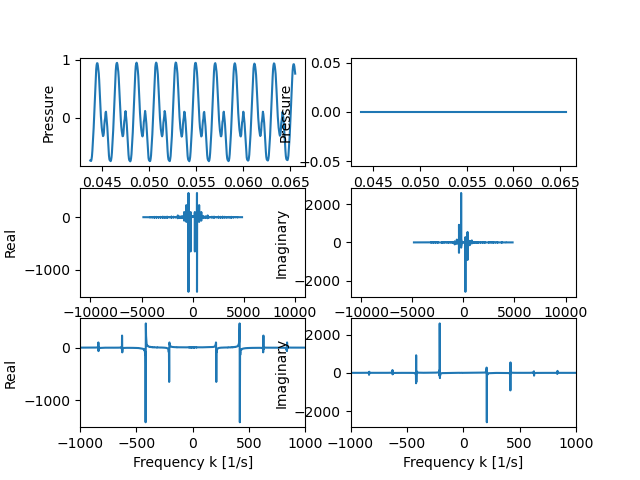

k and Amplitudes the real part of our FFT
386
k and Amplitudes the imaginary part of our FFT
242


In [3]:
filename_2 = 'PHY64_bb5 2.wav'

Info_2 = Generator(filename_2)

Plotter(Info_2[0], Info_2[1], Info_2[2], Info_2[3], 0.1, 0.15)

Amps(Info_2[0], Info_2[1], Info_2[2], Info_2[3])